In [3]:
# (0) Importamos librerías básicas para EDA y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# (0B) Si lo subiste al runtime de Colab, suele quedar en /content/

df = pd.read_csv(
    "ETAPA 1 - CONSTRUCCIÓN BASE DE DATOS/outputs/desigualdad_3ciudades.csv.gz",
    compression="gzip",
    low_memory=False
)

print("Dataset cargado:", df.shape)
df.head()

Dataset cargado: (2508180, 34)


,COD_DANE_ANM,HA_TOT_PER,H_NRO_CUARTOS,H_NRO_DORMIT,PA1_CALIDAD_SERV,PA_ASISTENCIA,PA_LO_ATENDIERON,P_ALFABETA,P_EDADR,P_ENFERMO,...,VA_EE,VB_ACU,VC_ALC,VD_GAS,VE_RECBAS,VF_INTERNET,V_CON_OCUP,V_MAT_PARED,V_MAT_PISO,V_TIPO_VIV
0,6300110000000000010115,4.0,3.0,2.0,1.0,2.0,1.0,1.0,13,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0
1,6300110000000000010115,4.0,3.0,2.0,NaN,2.0,NaN,1.0,13,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0
2,6300110000000000010115,4.0,3.0,2.0,NaN,1.0,NaN,1.0,6,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0
3,6300110000000000010115,4.0,3.0,2.0,NaN,1.0,NaN,1.0,3,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0
4,6300110000000000010115,5.0,3.0,2.0,NaN,2.0,NaN,1.0,7,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0


In [5]:
required = ["COD_DANE_ANM", "U_DPTO", "U_MPIO"]
missing = [c for c in required if c not in df.columns]
print("Faltan columnas clave:", missing if missing else "NINGUNA ✅")

print("Nulos en COD_DANE_ANM:", df["COD_DANE_ANM"].isna().sum())

print("Longitudes de COD_DANE_ANM:")
print(df["COD_DANE_ANM"].astype(str).str.len().value_counts().head(10))

Faltan columnas clave: NINGUNA ✅
Nulos en COD_DANE_ANM: 0
Longitudes de COD_DANE_ANM:
COD_DANE_ANM
22    2508180
Name: count, dtype: int64


In [6]:
df_clean = df.copy()


In [7]:
manzanas_mpio = (
    df_clean
    .groupby(["U_DPTO", "U_MPIO"])["COD_DANE_ANM"]
    .nunique()
    .reset_index(name="N_MANZANAS")
)
manzanas_mpio


,U_DPTO,U_MPIO,N_MANZANAS
0,63,1,3199
1,66,1,4092
2,76,1,13690


In [8]:
pob_manzana = (
    df_clean
    .groupby("COD_DANE_ANM")
    .size()
    .reset_index(name="POBLACION")
)
pob_manzana.describe()


,POBLACION
count,20981.000000
mean,119.545303
std,156.837647
min,1.000000
25%,52.000000
50%,92.000000
75%,147.000000
max,11134.000000


In [9]:
pob_manzana_mpio = (
    df_clean
    .groupby(["U_DPTO", "U_MPIO", "COD_DANE_ANM"])
    .size()
    .reset_index(name="POBLACION")
    .groupby(["U_DPTO", "U_MPIO"])["POBLACION"]
    .describe()
)
pob_manzana_mpio


,,count,mean,std,min,25%,50%,75%,max
U_DPTO,U_MPIO,,,,,,,,
63,1,3199.0,86.164739,109.270073,5.0,41.0,65.0,99.0,2658.0
66,1,4092.0,100.114858,151.043590,4.0,42.0,71.0,111.0,3670.0
76,1,13690.0,133.153324,165.932155,1.0,63.0,109.0,165.0,11134.0


In [10]:
df_clean["COD_MPIO"] = (
    df_clean["U_DPTO"].astype(str).str.zfill(2) +
    df_clean["U_MPIO"].astype(str).str.zfill(3)
)


In [11]:
import numpy as np
import pandas as pd

# Asegura numéricos
per = pd.to_numeric(df_clean["HA_TOT_PER"], errors="coerce")
dorm = pd.to_numeric(df_clean["H_NRO_DORMIT"], errors="coerce").replace(0, np.nan)

df_clean["HACINAMIENTO"] = per / dorm


<Figure size 700x500 with 0 Axes>

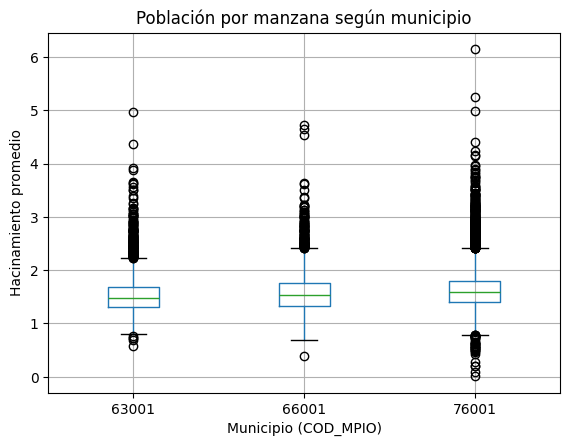

In [12]:
hacin_mpio = (
    df_clean
    .groupby(["COD_MPIO", "COD_DANE_ANM"])["HACINAMIENTO"]
    .mean()
    .reset_index()
)


plt.figure(figsize=(7,5))
hacin_mpio.boxplot(column="HACINAMIENTO", by="COD_MPIO")
plt.title("Población por manzana según municipio")
plt.suptitle("")
plt.xlabel("Municipio (COD_MPIO)")
plt.ylabel("Hacinamiento promedio")
plt.show()


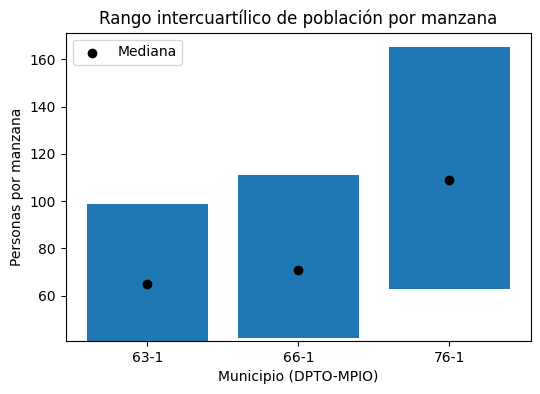

In [13]:
# Percentiles por municipio
percentiles = (
    df_clean
    .groupby(["U_DPTO","U_MPIO","COD_DANE_ANM"])
    .size()
    .reset_index(name="POBLACION")
    .groupby(["U_DPTO","U_MPIO"])["POBLACION"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(
    percentiles["U_DPTO"].astype(str) + "-" + percentiles["U_MPIO"].astype(str),
    percentiles[0.75] - percentiles[0.25],
    bottom=percentiles[0.25]
)

plt.scatter(
    percentiles["U_DPTO"].astype(str) + "-" + percentiles["U_MPIO"].astype(str),
    percentiles[0.5],
    color="black",
    label="Mediana"
)

plt.title("Rango intercuartílico de población por manzana")
plt.xlabel("Municipio (DPTO-MPIO)")
plt.ylabel("Personas por manzana")
plt.legend()
plt.show()


In [14]:
# 1) Población por manzana
pob_manzana = (
    df_clean
    .groupby(["U_DPTO", "U_MPIO", "COD_DANE_ANM"])
    .size()
    .reset_index(name="POBLACION")
)

# 2) Resumen por municipio
resumen_municipio = (
    pob_manzana
    .groupby(["U_DPTO", "U_MPIO"])
    .agg(
        N_MANZANAS = ("COD_DANE_ANM", "nunique"),
        POB_TOTAL = ("POBLACION", "sum"),
        POB_PROM_MZ = ("POBLACION", "mean"),
        POB_MEDIANA_MZ = ("POBLACION", "median"),
        POB_MAX_MZ = ("POBLACION", "max")
    )
    .reset_index()
)

resumen_municipio


,U_DPTO,U_MPIO,N_MANZANAS,POB_TOTAL,POB_PROM_MZ,POB_MEDIANA_MZ,POB_MAX_MZ
0,63,1,3199,275641,86.164739,65.0,2658
1,66,1,4092,409670,100.114858,71.0,3670
2,76,1,13690,1822869,133.153324,109.0,11134


In [15]:
pip install geopandas pyogrio matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import geopandas as gpd

ruta = r"ETAPA 2 - GEOREFERENCIACIÓN DE DATA/SHAPEFILES MANZANA/MGN_URB_MANZANA.shp"
gdf = gpd.read_file(ruta)

print("✔ Shapefile cargado")
print(gdf.shape)
gdf.head()

✔ Shapefile cargado
(504996, 11)


,DPTO_CCDGO,MPIO_CCDGO,CLAS_CCDGO,CPOB_CCDGO,COD_SECC,MANZ_CCNCT,COD_AG,SHAPE_Leng,SHAPE_Area,MANZ_CCDGO,geometry
0,05,05001,1,05001000,05001100000000010101,0500110000000001010101,000001,0.003371,2.313257e-07,01,"POLYGON ((-75.54267 6.30182, -75.54262 6.30175..."
1,05,05001,1,05001000,05001100000000010101,0500110000000001010104,000002,0.002620,1.629524e-07,04,"POLYGON ((-75.54237 6.29968, -75.54235 6.29965..."
2,05,05001,1,05001000,05001100000000010101,0500110000000001010105,000003,0.003002,2.090910e-07,05,"POLYGON ((-75.5428 6.29964, -75.54277 6.29959,..."
3,05,05001,1,05001000,05001100000000010101,0500110000000001010108,000004,0.001944,1.573086e-07,08,"POLYGON ((-75.54386 6.29974, -75.54386 6.29975..."
4,05,05001,1,05001000,05001100000000010101,0500110000000001010109,000005,0.001469,9.901152e-08,09,"POLYGON ((-75.54481 6.29881, -75.54487 6.29874..."


In [17]:
print("CRS")
print(gdf.crs)


CRS
EPSG:4326


In [18]:
print("Columnas del shapefile:")
print(list(gdf.columns))


Columnas del shapefile:
['DPTO_CCDGO', 'MPIO_CCDGO', 'CLAS_CCDGO', 'CPOB_CCDGO', 'COD_SECC', 'MANZ_CCNCT', 'COD_AG', 'SHAPE_Leng', 'SHAPE_Area', 'MANZ_CCDGO', 'geometry']


In [19]:
# 10 ejemplos del código concatenado de manzana
print(gdf["MANZ_CCNCT"].astype(str).head(10).to_list())

# longitudes (cuántos dígitos tiene normalmente)
print(gdf["MANZ_CCNCT"].astype(str).str.len().value_counts().head(10))


['0500110000000001010101', '0500110000000001010104', '0500110000000001010105', '0500110000000001010108', '0500110000000001010109', '0500110000000001010110', '0500110000000001010111', '0500110000000001010112', '0500110000000001010114', '0500110000000001010115']
MANZ_CCNCT
22    504996
Name: count, dtype: int64


In [20]:
# columnas disponibles
print(df_clean.columns.tolist())


['COD_DANE_ANM', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT', 'PA1_CALIDAD_SERV', 'PA_ASISTENCIA', 'PA_LO_ATENDIERON', 'P_ALFABETA', 'P_EDADR', 'P_ENFERMO', 'P_NIVEL_ANOSR', 'P_NROHOG', 'P_NRO_PER', 'P_PARENTESCOR', 'P_SEXO', 'P_TRABAJO', 'UA1_LOCALIDAD', 'UA_CLASE', 'U_DPTO', 'U_MPIO', 'U_MZA', 'U_SECC_URB', 'U_SECT_URB', 'U_VIVIENDA', 'VA_EE', 'VB_ACU', 'VC_ALC', 'VD_GAS', 'VE_RECBAS', 'VF_INTERNET', 'V_CON_OCUP', 'V_MAT_PARED', 'V_MAT_PISO', 'V_TIPO_VIV', 'COD_MPIO', 'HACINAMIENTO']


In [21]:
# 10 ejemplos
print(df_clean["COD_DANE_ANM"].astype(str).head(10).to_list())

# longitudes
print(df_clean["COD_DANE_ANM"].astype(str).str.len().value_counts().head(10))


['6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115', '6300110000000000010115']
COD_DANE_ANM
22    2508180
Name: count, dtype: int64


In [22]:
import pandas as pd

# Cargar consolidado final (3 ciudades)
df = pd.read_csv(
    "desigualdad_3ciudades_FINAL.csv.gz",
    compression="gzip",
    low_memory=False
)

# Columna llave territorial
col = "COD_DANE_ANM"

# 1) ¿Existe la columna?
print("Existe columna:", col in df.columns)

# 2) Forzar a string (seguridad)
df[col] = df[col].astype(str).str.strip()
s = df[col]

# 3) ¿Hay nulos?
print("Nulos:", df[col].isna().sum())

# 4) Longitudes (deben ser 22)
print("Longitudes:")
print(s.str.len().value_counts())

# 5) Validación rápida por municipio (DPTO+MPIO)
df["DPTO_MPIO"] = s.str[:5]
print("\nManzanas únicas por municipio:")
print(df.groupby("DPTO_MPIO")[col].nunique())


Existe columna: True
Nulos: 0
Longitudes:
COD_DANE_ANM
22    2508180
Name: count, dtype: int64

Manzanas únicas por municipio:
DPTO_MPIO
63001     3199
66001     4092
76001    13690
Name: COD_DANE_ANM, dtype: int64


In [23]:
# Forzar a string (seguridad)
df["COD_DANE_ANM"] = df["COD_DANE_ANM"].astype(str).str.strip()
gdf["MANZ_CCNCT"]  = gdf["MANZ_CCNCT"].astype(str).str.strip()

# Extraer DPTO+MPIO (primeros 5 dígitos)
df["DPTO_MPIO"]  = df["COD_DANE_ANM"].str[:5]
gdf["DPTO_MPIO"] = gdf["MANZ_CCNCT"].str[:5]

# Municipios presentes en el censo
municipios = sorted(df["DPTO_MPIO"].unique())

print("Cobertura Censo vs SHP por municipio:\n")

for mpio in municipios:
    censo_codes = set(df.loc[df["DPTO_MPIO"] == mpio, "COD_DANE_ANM"].values)
    shape_codes = set(gdf.loc[gdf["DPTO_MPIO"] == mpio, "MANZ_CCNCT"].values)

    match = censo_codes & shape_codes

    cobertura = round(len(match) / len(censo_codes) * 100, 2) if len(censo_codes) > 0 else 0

    print(f"Municipio {mpio}")
    print("  Manzanas en Censo:", len(censo_codes))
    print("  Manzanas en SHP:  ", len(shape_codes))
    print("  Coinciden:        ", len(match))
    print("  Cobertura (%):    ", cobertura)
    print("-" * 40)

# (Opcional) cobertura total
all_censo  = set(df["COD_DANE_ANM"].values)
all_shape  = set(gdf["MANZ_CCNCT"].values)
all_match  = all_censo & all_shape

print("\nCobertura TOTAL:")
print("  Manzanas en Censo:", len(all_censo))
print("  Manzanas en SHP:  ", len(all_shape))
print("  Coinciden:        ", len(all_match))
print("  Cobertura (%):    ", round(len(all_match) / len(all_censo) * 100, 2))



Cobertura Censo vs SHP por municipio:

Municipio 63001
  Manzanas en Censo: 3199
  Manzanas en SHP:   3705
  Coinciden:         3190
  Cobertura (%):     99.72
----------------------------------------
Municipio 66001
  Manzanas en Censo: 4092
  Manzanas en SHP:   4787
  Coinciden:         3988
  Cobertura (%):     97.46
----------------------------------------
Municipio 76001
  Manzanas en Censo: 13690
  Manzanas en SHP:   15658
  Coinciden:         13617
  Cobertura (%):     99.47
----------------------------------------

Cobertura TOTAL:
  Manzanas en Censo: 20981
  Manzanas en SHP:   504996
  Coinciden:         20795
  Cobertura (%):     99.11


In [24]:
import pandas as pd
import os

# carpeta de salida
OUTPUT_DIR = "ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1) Normalizar llaves
df = df.copy()
gdf = gdf.copy()

df["COD_DANE_ANM"] = df["COD_DANE_ANM"].astype(str).str.strip()
gdf["MANZ_CCNCT"]  = gdf["MANZ_CCNCT"].astype(str).str.strip()

# 2) Seleccionar columnas útiles del shapefile
shape_cols = [c for c in gdf.columns if c != "geometry"]

gdf_tab = gdf[shape_cols + ["geometry"]].copy()
gdf_tab["GEOM_WKT"] = gdf_tab["geometry"].to_wkt()
gdf_tab = gdf_tab.drop(columns=["geometry"])

# evitar duplicados por manzana
gdf_tab = gdf_tab.drop_duplicates(subset=["MANZ_CCNCT"], keep="first")

# 3) Join censo + shapefile
censo_geo = df.merge(
    gdf_tab,
    how="left",
    left_on="COD_DANE_ANM",
    right_on="MANZ_CCNCT"
)

# 4) Separar los que no matchean
sin_geom = censo_geo[censo_geo["GEOM_WKT"].isna()].copy()
con_geom = censo_geo[~censo_geo["GEOM_WKT"].isna()].copy()

print("Total censo:", len(df))
print("Con geometría:", len(con_geom))
print("Sin geometría:", len(sin_geom))
print("Cobertura (%):", round(len(con_geom)/len(df)*100, 2))

# 5) Guardar outputs
con_geom.to_csv(
    f"{OUTPUT_DIR}/censo_georeferencia.csv",
    index=False
)

sin_geom[["COD_DANE_ANM"]].drop_duplicates().to_csv(
    f"{OUTPUT_DIR}/censo_sin_geometria.csv",
    index=False
)

print("✔ Guardado:", f"{OUTPUT_DIR}/censo_georeferencia.csv")
print("✔ Guardado:", f"{OUTPUT_DIR}/censo_sin_geometria.csv")

Total censo: 2508180
Con geometría: 2449375
Sin geometría: 58805
Cobertura (%): 97.66
✔ Guardado: ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs/censo_georeferencia.csv
✔ Guardado: ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs/censo_sin_geometria.csv


In [25]:
import pandas as pd

censo_geo = pd.read_csv("censo_georeferencia.csv", low_memory=False)

print("Columnas censo_georeferencia:")
print(censo_geo.columns.tolist())

print("\nPrimeras 5 filas:")
censo_geo.head()


Columnas censo_georeferencia:
['COD_DANE_ANM', 'HA_TOT_PER', 'H_NRO_CUARTOS', 'H_NRO_DORMIT', 'PA1_CALIDAD_SERV', 'PA_ASISTENCIA', 'PA_LO_ATENDIERON', 'P_ALFABETA', 'P_EDADR', 'P_ENFERMO', 'P_NIVEL_ANOSR', 'P_NROHOG', 'P_NRO_PER', 'P_PARENTESCOR', 'P_SEXO', 'P_TRABAJO', 'UA1_LOCALIDAD', 'UA_CLASE', 'U_DPTO', 'U_MPIO', 'U_MZA', 'U_SECC_URB', 'U_SECT_URB', 'U_VIVIENDA', 'VA_EE', 'VB_ACU', 'VC_ALC', 'VD_GAS', 'VE_RECBAS', 'VF_INTERNET', 'V_CON_OCUP', 'V_MAT_PARED', 'V_MAT_PISO', 'V_TIPO_VIV', 'DPTO_MPIO_x', 'DPTO_CCDGO', 'MPIO_CCDGO', 'CLAS_CCDGO', 'CPOB_CCDGO', 'COD_SECC', 'MANZ_CCNCT', 'COD_AG', 'SHAPE_Leng', 'SHAPE_Area', 'MANZ_CCDGO', 'DPTO_MPIO_y', 'GEOM_WKT']

Primeras 5 filas:


,COD_DANE_ANM,HA_TOT_PER,H_NRO_CUARTOS,H_NRO_DORMIT,PA1_CALIDAD_SERV,PA_ASISTENCIA,PA_LO_ATENDIERON,P_ALFABETA,P_EDADR,P_ENFERMO,...,CLAS_CCDGO,CPOB_CCDGO,COD_SECC,MANZ_CCNCT,COD_AG,SHAPE_Leng,SHAPE_Area,MANZ_CCDGO,DPTO_MPIO_y,GEOM_WKT
0,6300110000000000010115,4.0,3.0,2.0,1.0,2.0,1.0,1.0,13,1.0,...,1,63001000,63001100000000000101,6300110000000000010115,715240,0.002082,1.382203e-07,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518..."
1,6300110000000000010115,4.0,3.0,2.0,NaN,2.0,NaN,1.0,13,2.0,...,1,63001000,63001100000000000101,6300110000000000010115,715240,0.002082,1.382203e-07,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518..."
2,6300110000000000010115,4.0,3.0,2.0,NaN,1.0,NaN,1.0,6,2.0,...,1,63001000,63001100000000000101,6300110000000000010115,715240,0.002082,1.382203e-07,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518..."
3,6300110000000000010115,4.0,3.0,2.0,NaN,1.0,NaN,1.0,3,2.0,...,1,63001000,63001100000000000101,6300110000000000010115,715240,0.002082,1.382203e-07,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518..."
4,6300110000000000010115,5.0,3.0,2.0,NaN,2.0,NaN,1.0,7,2.0,...,1,63001000,63001100000000000101,6300110000000000010115,715240,0.002082,1.382203e-07,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518..."


In [26]:
import pandas as pd

# tomar las primeras 10 filas
preview = censo_geo.head(10)

# ruta de salida
out_path = "ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs/censo_georeferencia_preview.xlsx"

# exportar
preview.to_excel(out_path, index=False)

print("Archivo creado:", out_path)

Archivo creado: ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs/censo_georeferencia_preview.xlsx


In [27]:
import pandas as pd

path = "ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs/censo_sin_geometria.csv"

censo_sin = pd.read_csv(path, low_memory=False)

print("Columnas censo_sin_geometria:")
print(censo_sin.columns.tolist())

print("\nPrimeras 10 llaves sin geometría:")
censo_sin.head(10)

Columnas censo_sin_geometria:
['COD_DANE_ANM']

Primeras 10 llaves sin geometría:


,COD_DANE_ANM
0,6300110000000000000000
1,6300120010400900000000
2,6300120000000000000000
3,6300130010300000000000
4,6300130010200000000000
5,6300130010100000000000
6,6300130010400000000000
7,6300130020100000000000
8,6300130000000000000000
9,6600110000000000000000
